##### Surge pricing model

In [ ]:
# import library
import pandas as pd

In [ ]:
#loading of dataset
df = pd.read_csv('yellow_tripdata_2015-01.csv')

In [55]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [3]:
df.shape

(12748986, 19)

In [ ]:
# checking for null values
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RateCodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    3
total_amount             0
dtype: int64

In [5]:
df = df.dropna()

In [ ]:
# dropping data with zero lat and long
df[(df[["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]] == 0).any(axis=1)]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
31,2,2015-01-15 19:05:43,2015-01-15 19:05:44,2,0.01,0.0,0.0,5,N,0.000000,0.000000,1,60.0,0.0,0.0,0.00,0.00,0.3,60.30
61,1,2015-01-04 13:44:52,2015-01-04 13:56:49,1,2.50,0.0,0.0,1,N,0.000000,0.000000,1,11.0,0.0,0.5,2.35,0.00,0.0,14.15
66,2,2015-01-04 13:44:52,2015-01-04 13:49:03,1,0.85,0.0,0.0,1,N,0.000000,0.000000,2,5.5,0.0,0.5,0.00,0.00,0.3,6.30
157,1,2015-01-15 09:47:00,2015-01-15 10:00:07,1,1.00,0.0,0.0,1,N,0.000000,0.000000,2,10.0,0.0,0.5,0.00,0.00,0.3,10.80
159,1,2015-01-15 09:47:02,2015-01-15 10:17:47,3,8.30,0.0,0.0,1,N,0.000000,0.000000,1,27.5,0.0,0.5,10.00,5.33,0.3,43.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12748593,2,2015-01-25 20:00:10,2015-01-25 20:10:34,1,3.27,0.0,0.0,1,N,0.000000,0.000000,2,11.5,0.5,0.5,0.00,0.00,0.3,12.80
12748692,2,2015-01-10 06:07:11,2015-01-10 06:26:42,6,7.62,0.0,0.0,1,N,0.000000,0.000000,1,23.5,0.0,0.5,1.50,0.00,0.3,25.80
12748789,1,2015-01-10 17:55:38,2015-01-10 18:04:24,1,1.20,0.0,0.0,1,N,0.000000,0.000000,2,7.5,0.0,0.5,0.00,0.00,0.3,8.30
12748817,1,2015-01-10 18:16:46,2015-01-10 18:27:37,1,1.40,0.0,0.0,1,N,0.000000,0.000000,1,9.0,0.0,0.5,2.45,0.00,0.3,12.25


In [8]:
df = df[(df[["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]] != 0).any(axis=1)]

In [ ]:
# dropping rows with 0 values (incorrect data)
df[(df[["passenger_count", "trip_distance", "total_amount", "passenger_count"]] == 0).any(axis=1)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
132,1,2015-01-15 10:26:16,2015-01-15 10:26:42,2,0.0,-73.987656,40.743645,5,N,-73.987488,40.743484,1,60.0,0.0,0.0,15.0,0.0,0.3,75.3
133,1,2015-01-15 10:26:17,2015-01-15 10:27:28,1,0.0,-73.946526,40.744991,1,N,-73.946526,40.744991,2,3.0,0.0,0.5,0.0,0.0,0.3,3.8
372,1,2015-01-01 01:08:56,2015-01-01 01:08:56,4,0.0,-73.980789,40.676605,1,Y,0.000000,0.000000,2,20.0,0.5,0.5,0.0,0.0,0.0,21.3
629,2,2015-01-25 17:45:15,2015-01-25 17:45:21,1,0.0,-73.975655,40.761318,2,N,0.000000,0.000000,1,52.0,0.0,0.5,20.0,0.0,0.3,72.8
707,1,2015-01-10 20:14:23,2015-01-10 20:14:36,1,0.0,-73.993271,40.748833,1,N,-73.993271,40.748833,3,2.5,0.5,0.5,0.0,0.0,0.3,3.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12748477,1,2015-01-10 16:02:49,2015-01-10 16:02:52,1,0.0,-73.790611,40.644199,1,N,-73.790611,40.644199,3,2.5,0.0,0.5,0.0,0.0,0.3,3.3
12748621,2,2015-01-29 20:11:11,2015-01-29 20:11:15,1,0.0,-73.990959,40.739792,2,N,-73.990921,40.739769,2,52.0,0.0,0.5,0.0,0.0,0.3,52.8
12748645,1,2015-01-26 10:06:21,2015-01-26 10:06:48,1,0.0,-73.776711,40.645283,1,N,-73.776810,40.645817,3,2.5,0.0,0.5,0.0,0.0,0.3,3.3
12748738,1,2015-01-26 10:53:59,2015-01-26 10:54:03,1,0.0,-73.948990,40.744835,1,N,-73.949005,40.744877,2,2.5,1.0,0.0,0.0,0.0,0.3,3.8


In [10]:
df = df[(df[["passenger_count", "trip_distance", "total_amount","passenger_count"]] != 0).any(axis=1)]

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12534837 entries, 0 to 12748985
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.9+ GB


##### EDA(Exploratory Data Analysis)

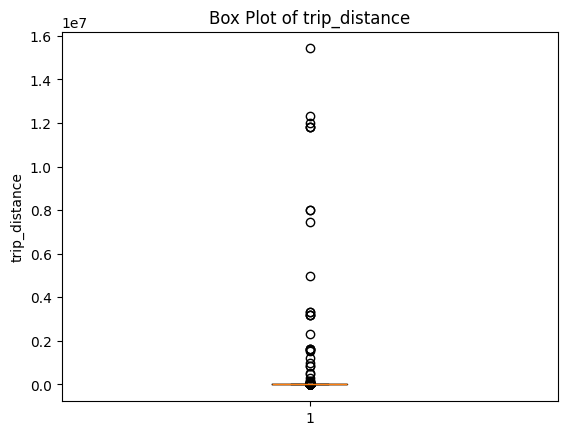

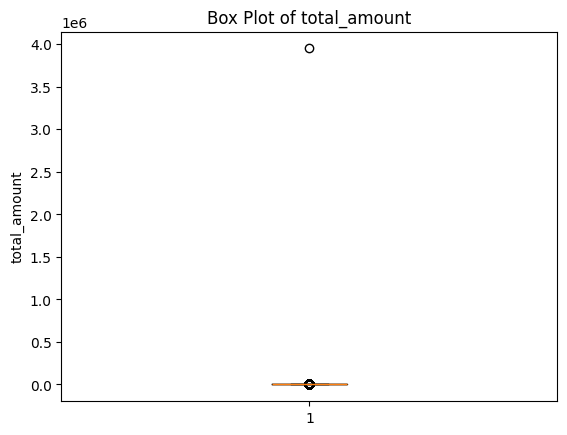

In [12]:
# data distribution for features like 
# trip_distance, total_amount using box plots

import matplotlib.pyplot as plt

features = ["trip_distance", "total_amount"]

for col in features:
    plt.figure()
    plt.boxplot(df[col].dropna())  # Drop NaN to avoid errors
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

In [13]:
df['trip_distance'].describe()

count    1.253484e+07
mean     1.364575e+01
std      9.927828e+03
min      0.000000e+00
25%      1.000000e+00
50%      1.680000e+00
75%      3.000000e+00
max      1.542000e+07
Name: trip_distance, dtype: float64

In [ ]:
# removing outliers from trip distance
Q1 = df["trip_distance"].quantile(0.25)
Q3 = df["trip_distance"].quantile(0.75)
IQR = Q3 - Q1

In [16]:
df = df[(df["trip_distance"] > 1) & (df["trip_distance"] <= Q3 + 1.5 * IQR)]

In [17]:
print(df["trip_distance"].describe())

count    7.968291e+06
mean     2.348269e+00
std      1.176099e+00
min      1.010000e+00
25%      1.410000e+00
50%      2.000000e+00
75%      2.950000e+00
max      6.000000e+00
Name: trip_distance, dtype: float64


In [ ]:
# removing data with invalid entires of total_amount
df[(df["total_amount"] > 0)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30
6,1,2015-01-10 20:33:39,2015-01-10 20:58:31,1,2.20,-73.983276,40.726009,1,N,-73.992470,40.749634,2,14.0,0.5,0.5,0.00,0.0,0.3,15.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12748978,1,2015-01-10 19:01:43,2015-01-10 19:12:05,1,1.60,-73.984421,40.748260,1,N,-73.989220,40.730583,1,8.5,0.0,0.5,2.30,0.0,0.3,11.60
12748979,1,2015-01-10 19:01:43,2015-01-10 19:27:13,1,2.30,-73.994240,40.750805,1,N,-73.988686,40.730900,2,16.5,0.0,0.5,0.00,0.0,0.3,17.30
12748980,1,2015-01-10 19:01:44,2015-01-10 19:20:09,1,2.10,-73.980827,40.744530,1,N,-74.008873,40.740929,1,13.0,0.0,0.5,1.50,0.0,0.3,15.30
12748983,1,2015-01-10 19:01:44,2015-01-10 19:15:01,1,3.40,-73.979324,40.749550,1,N,-73.969101,40.787800,2,13.5,0.0,0.5,0.00,0.0,0.3,14.30


In [ ]:
# handing fare amount
df['fare_amount'].max()

4008.0

In [21]:
Q11 = df["fare_amount"].quantile(0.25)
Q31 = df["fare_amount"].quantile(0.75)
IQR1 = Q31 - Q11

df = df[(df["fare_amount"] >= Q11 - 1.5 * IQR1) & (df["fare_amount"] <= Q31 + 1.5 * IQR1)]

In [22]:
df['fare_amount'].describe()

count    7.792564e+06
mean     1.065180e+01
std      3.581654e+00
min      5.000000e-01
25%      8.000000e+00
50%      1.000000e+01
75%      1.300000e+01
max      2.050000e+01
Name: fare_amount, dtype: float64

In [ ]:
# Convert to datetime format
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# Calculate trip duration in minutes
df["trip_duration_min"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Show result
print(df[["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_duration_min"]].head())


  tpep_pickup_datetime tpep_dropoff_datetime  trip_duration_min
0  2015-01-15 19:05:39   2015-01-15 19:23:42          18.050000
1  2015-01-10 20:33:38   2015-01-10 20:53:28          19.833333
2  2015-01-10 20:33:38   2015-01-10 20:43:41          10.050000
4  2015-01-10 20:33:39   2015-01-10 20:52:58          19.316667
6  2015-01-10 20:33:39   2015-01-10 20:58:31          24.866667


In [ ]:
# handling outliers in trip duration
df["trip_duration_min"].describe()

NameError: name 'df' is not defined

In [26]:
df[df['trip_duration_min'] >= 500] 

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_min
4012,2,2015-01-13 18:37:53,2015-01-14 18:36:39,1,2.73,-73.974449,40.752071,1,N,-74.008911,40.735668,1,13.5,1.0,0.5,1.45,0.0,0.3,16.75,1438.766667
6698,2,2015-01-24 09:27:33,2015-01-25 00:00:00,5,1.29,-73.942734,40.805813,1,N,-73.952759,40.791946,1,6.0,0.0,0.5,0.34,0.0,0.3,7.14,872.450000
10944,2,2015-01-18 09:26:20,2015-01-19 09:17:51,1,1.05,-73.974533,40.783356,1,N,-73.983070,40.777527,2,5.5,0.0,0.5,0.00,0.0,0.3,6.30,1431.516667
11014,2,2015-01-28 13:47:45,2015-01-29 13:27:21,1,2.97,-73.992340,40.750309,1,N,-73.982689,40.719887,1,15.5,0.0,0.5,1.63,0.0,0.3,17.93,1419.600000
12347,2,2015-01-07 09:26:08,2015-01-08 09:23:56,1,1.90,-73.959496,40.771202,1,N,-73.975304,40.787861,1,9.0,0.0,0.5,1.80,0.0,0.3,11.60,1437.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12742382,2,2015-01-04 01:43:59,2015-01-05 00:00:00,1,2.51,-73.989998,40.756969,1,N,-73.961037,40.765259,2,10.0,0.5,0.5,0.00,0.0,0.3,11.30,1336.016667
12743248,2,2015-01-03 13:19:41,2015-01-04 13:16:27,1,1.04,-73.977631,40.763588,1,N,-73.985588,40.757896,2,12.0,0.0,0.5,0.00,0.0,0.3,12.80,1436.766667
12744082,2,2015-01-10 23:55:26,2015-01-11 23:34:51,1,1.97,-73.960701,40.816940,1,N,-73.966904,40.793709,1,9.5,0.5,0.5,0.50,0.0,0.3,11.30,1419.416667
12745381,2,2015-01-09 20:48:45,2015-01-10 20:36:56,2,4.88,-73.949074,40.711189,1,N,-73.932709,40.670727,1,17.5,0.5,0.5,2.70,0.0,0.3,21.50,1428.183333


In [27]:
df = df[df['trip_duration_min'] > 0] 
df = df[df['trip_duration_min'] <= 500] 

In [28]:
df['trip_duration_min'].describe()

count    7.786482e+06
mean     1.224712e+01
std      5.994379e+00
min      1.666667e-02
25%      8.183333e+00
50%      1.121667e+01
75%      1.533333e+01
max      4.992000e+02
Name: trip_duration_min, dtype: float64

In [29]:
# Define bins and labels
bins = [0, 15, 30, float('inf')]
labels = ['short', 'medium', 'long']

# Create category column
df['trip_duration_category'] = pd.cut(df['trip_duration_min'], bins=bins, labels=labels, right=False)

df[['trip_duration_min', 'trip_duration_category']].head()


,trip_duration_min,trip_duration_category
0,18.050000,medium
1,19.833333,medium
2,10.050000,short
4,19.316667,medium
6,24.866667,medium


In [31]:
df = df[df['passenger_count']>0]

In [ ]:
# handling fare_amount per km per person 
df['fare_amount_per_km_person'] = df['fare_amount'] / df['trip_distance'] * df['passenger_count']

In [33]:
df['fare_amount_per_km_person'].describe()

count    7.782893e+06
mean     8.533383e+00
std      7.258741e+00
min      2.400000e-01
25%      4.473684e+00
50%      5.468750e+00
75%      9.090909e+00
max      9.611650e+01
Name: fare_amount_per_km_person, dtype: float64

In [34]:
Q12 = df['fare_amount_per_km_person'].quantile(0.25)
Q32 = df['fare_amount_per_km_person'].quantile(0.75)
IQR2 = Q32 - Q12
upper_limit = Q32 + 1.5 * IQR2

df = df[df['fare_amount_per_km_person'] <= upper_limit]


In [36]:
# Filter NYC coordinates only
df = df[(df['pickup_latitude'].between(40, 42)) &
        (df['pickup_longitude'].between(-75, -72)) &
        (df['dropoff_latitude'].between(40, 42)) &
        (df['dropoff_longitude'].between(-75, -72))]

In [37]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_min,trip_duration_category,fare_amount_per_km_person
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,N,-73.974785,...,12.0,1.0,0.5,3.25,0.0,0.3,17.05,18.050000,medium,7.547170
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1,N,-73.994415,...,14.5,0.5,0.5,2.00,0.0,0.3,17.80,19.833333,medium,4.393939
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1,N,-73.951820,...,9.5,0.5,0.5,0.00,0.0,0.3,10.80,10.050000,short,5.277778
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1,N,-74.004181,...,15.0,0.5,0.5,0.00,0.0,0.3,16.30,19.316667,medium,5.000000
6,1,2015-01-10 20:33:39,2015-01-10 20:58:31,1,2.20,-73.983276,40.726009,1,N,-73.992470,...,14.0,0.5,0.5,0.00,0.0,0.3,15.30,24.866667,medium,6.363636


In [38]:
columns_to_drop = ['store_and_fwd_flag', 'extra', 'mta_tax', 'improvement_surcharge', 'VendorID','RateCodeID','tip_amount', 'tolls_amount']
df = df.drop(columns=columns_to_drop, axis=1)


In [39]:
df.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,total_amount,trip_duration_min,trip_duration_category,fare_amount_per_km_person
0,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,-73.974785,40.750618,1,12.0,17.05,18.050000,medium,7.547170
1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,-73.994415,40.759109,1,14.5,17.80,19.833333,medium,4.393939
2,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,-73.951820,40.824413,2,9.5,10.80,10.050000,short,5.277778
4,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,-74.004181,40.742653,2,15.0,16.30,19.316667,medium,5.000000
6,2015-01-10 20:33:39,2015-01-10 20:58:31,1,2.20,-73.983276,40.726009,-73.992470,40.749634,2,14.0,15.30,24.866667,medium,6.363636


In [40]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [41]:
# Pickup date (YYYY-MM-DD)
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date

# Pickup hour (0 to 23)
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour


In [42]:
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()  # Monday, Tuesday...
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['is_weekend'] = df['pickup_day_of_week'].isin(['Saturday', 'Sunday']).astype(int)


In [44]:
columns_to_drop = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'payment_type','total_amount','fare_amount_per_km_person']
df = df.drop(columns=columns_to_drop, axis=1)

##### Zone creatation 

In [45]:
from sklearn.cluster import KMeans

# Selecting coordinates
pickup_coords = df[['pickup_latitude', 'pickup_longitude']]
dropoff_coords = df[['dropoff_latitude', 'dropoff_longitude']]

# Apply KMeans
kmeans_pickup = KMeans(n_clusters=50, random_state=42)
df['pickup_zone_d'] = kmeans_pickup.fit_predict(pickup_coords)
df['dropoff_zone_d'] = kmeans_pickup.fit_predict(dropoff_coords)

##### Model training 

In [100]:
!pip install xgboost

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Encode categorical features
le1 = LabelEncoder()
df['trip_duration_category'] = le1.fit_transform(df['trip_duration_category'])

le2 = LabelEncoder()
df['pickup_day_of_week'] = le2.fit_transform(df['pickup_day_of_week'])

le3 = LabelEncoder()
df['pickup_zone_d'] = le3.fit_transform(df['pickup_zone_d'])
le4 = LabelEncoder()
df['dropoff_zone_d'] = le4.fit_transform(df['dropoff_zone_d'])

# Drop unwanted columns
df1 = df.drop(columns=['pickup_date'], errors='ignore')

# Features and Target
X = df1.drop(columns=['fare_amount'])
y = df1['fare_amount']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))



MAE: 0.2401712736618232
R2 Score: 0.9856003918771098


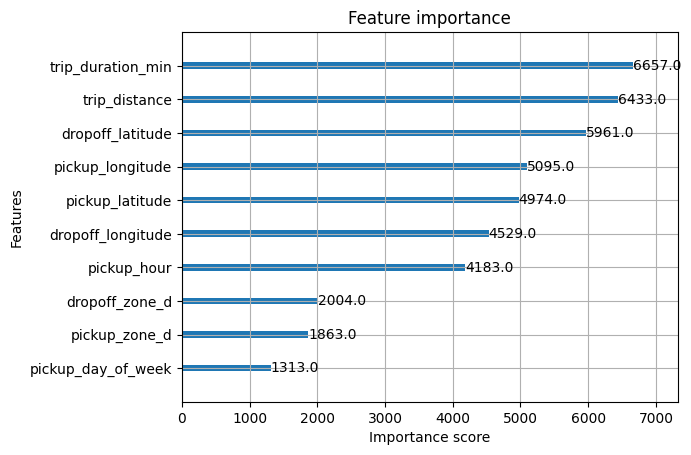

In [48]:
import matplotlib.pyplot as plt
import xgboost as xgb

xgb.plot_importance(model, max_num_features=10)
plt.show()


In [52]:
import numpy as np

# Example data as a single row (2D array)
sample_input = np.array([[2, 5.2, -73.9855, 40.7484, -73.9851, 40.7580,
                          16, 1, 18, 4, 6, 0, 9 , 3]])

# Predict fare
predicted_fare = model.predict(sample_input)
print("Predicted Fare Amount: $", round(predicted_fare[0], 2))


Predicted Fare Amount: $ 17.45


##### Demand forecasting

In [53]:
df['demand_1'] = df.groupby(['pickup_zone_d', 'pickup_date', 'pickup_hour'])['passenger_count'].transform('count')
features_for_demand = [
    'pickup_zone_d',
    'pickup_hour',
    'pickup_day_of_week',
    'pickup_month',
    'is_weekend'
]



In [54]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X_demand = df[features_for_demand]
y_demand = df['demand_1']

X_train, X_test, y_train, y_test = train_test_split(X_demand, y_demand, test_size=0.2, random_state=42)

xgb_demand = XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.1)
xgb_demand.fit(X_train, y_train)

y_pred_demand = xgb_demand.predict(X_test)
print("Demand MAE:", mean_absolute_error(y_test, y_pred_demand))
print("Demand R2:", r2_score(y_test, y_pred_demand))


Demand MAE: 45.008056640625
Demand R2: 0.894784688949585


In [55]:
import numpy as np

# Example test input
# pickup_zone_d, pickup_hour, pickup_day_of_week, pickup_month, is_weekend
sample_input = np.array([[10, 18, 4, 6, 1]])

# Predict demand
predicted_demand = xgb_demand.predict(sample_input)
print("Predicted Demand (number of rides):", round(predicted_demand[0], 2))



Predicted Demand (number of rides): 29.14


#### Final Testing for fare price , demand forecasting  and Surge price

In [64]:
import numpy as np
import pandas as pd

# ===== USER INPUT SAMPLE =====
user_input = {
    'passenger_count': 2,
    'trip_distance': 5.3,
    'pickup_longitude': -73.985,
    'pickup_latitude': 40.748,
    'dropoff_longitude': -73.975,
    'dropoff_latitude': 40.758,
    'trip_duration_min': 12,
    'trip_duration_category': 1,  # 0=short,1=medium,2=long (your encoding)
    'pickup_hour': 18,
    'pickup_day_of_week': 3,  # 0=Mon,6=Sun
    'pickup_month': 10,
    'is_weekend': 0,
    'pickup_zone_d': 12,
    'dropoff_zone_d': 45
}

# Convert input to DataFrame
input_df = pd.DataFrame([user_input])

# ===== FARE FEATURES =====
fare_features = [
    'passenger_count', 'trip_distance', 'pickup_longitude',
    'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
    'trip_duration_min', 'trip_duration_category', 'pickup_hour',
    'pickup_day_of_week', 'pickup_month', 'is_weekend',
    'pickup_zone_d', 'dropoff_zone_d'
]

# Predict fare
predicted_fare = model.predict(input_df[fare_features])[0]

# ===== DEMAND FEATURES =====
demand_features = [
    'pickup_zone_d', 'pickup_hour', 'pickup_day_of_week',
    'pickup_month', 'is_weekend'
]

predicted_demand = xgb_demand.predict(input_df[demand_features])[0]

# ===== SUPPLY FORMULA =====
pickup_hour = user_input['pickup_hour']
if pickup_hour in [8,9,18,19,20]:
    supply = predicted_demand * 0.7
elif pickup_hour in [6,7,10,17,21]:
    supply = predicted_demand * 0.9
else:
    supply = predicted_demand * 1.1

# ===== SURGE MULTIPLIER =====
if supply == 0:
    supply = 1

surge_multiplier = 1 + (predicted_demand - supply) / supply
surge_multiplier = max(1, surge_multiplier)

# ===== FINAL SURGE PRICE =====
surge_price = predicted_fare * surge_multiplier

# ===== OUTPUT =====
print("===== PREDICTION RESULT =====")
print(f"Base Fare Price      : ${predicted_fare:.2f}")
print(f"Predicted Demand     : {predicted_demand:.2f}")
print(f"Estimated Supply     : {supply:.2f}")
print(f"Surge Multiplier     : {surge_multiplier:.2f}")
print(f"Final Surge Price    : ${surge_price:.2f}")


===== PREDICTION RESULT =====
Base Fare Price      : $17.11
Predicted Demand     : 4.42
Estimated Supply     : 3.09
Surge Multiplier     : 1.43
Final Surge Price    : $24.44
